In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import linalg
import networkx as nx # 用于生成复杂的异质拓扑
from scipy.stats import ortho_group
from scipy import stats

In [2]:
def init_matrix_with_controlled_spectrum(N, distribution='uniform', bounds=(0.1, 1.0), symmetric=True):
    """
    初始化权重矩阵 W，并强制其精度矩阵 A = WW^T 具有特定的谱分布和增强的非对角相关性。

    Args:
        N (int): 维度。
        distribution (str): 谱分布类型 ('uniform', 'power_law', 'bimodal')。
        bounds (tuple): 特征值范围 (min, max)。
        symmetric (bool): True=对称W, False=非对称W (Dale兼容)。
        align_mean_mode (bool): 
            - True (关键修改): 强制第一个特征向量指向 [1,1...1]。这会将 lambda[0] 的能量
              广播到整个矩阵的非对角元，使 A_ij 的量级不再趋于 0。
            - False: 纯随机旋转，A_ij 通常为 O(1/sqrt(N))，远小于 A_ii。

    Returns:
        W (ndarray): 权重矩阵。
        A (ndarray): 精度矩阵。
    """
    # --- 1. 生成 A 的特征向量基 Q (Output Basis) ---

    # 原始逻辑：纯随机基 (导致 A 接近对角阵)
    if N < 1000:
        Q = ortho_group.rvs(N)
    else:
        H = np.random.randn(N, N)
        Q, _ = linalg.qr(H)

    # --- 2. 定义 A 的目标谱 (Eigenvalues) ---
    if distribution == 'orthogonal':
        lambdas = np.ones(N) # A = I
    
    elif distribution == 'uniform':
        low, high = bounds
        lambdas = np.random.uniform(low, high, N)
        
    elif distribution == 'power_law':
        # 幂律分布 (Sloppy Model 常用)
        alpha = 1.0
        x = np.random.uniform(0, 1, N)
        lambdas = (1 - x) ** (-1/alpha)
        # 映射到 bounds
        l_min, l_max = lambdas.min(), lambdas.max()
        lambdas = bounds[0] + (lambdas - l_min) * (bounds[1] - bounds[0]) / (l_max - l_min)
        
    elif distribution == 'bimodal':
        # 双峰分布：模拟 E-I 分离的强相互作用
        # 一半很强(Stiff)，一半很弱(Sloppy)
        mid = N // 2
        lambdas = np.zeros(N)
        lambdas[:mid] = np.random.uniform(bounds[0], bounds[0]*10, mid) # Sloppy
        lambdas[mid:] = np.random.uniform(bounds[1]/10, bounds[1], N-mid) # Stiff
        
    else:
        raise ValueError("Unknown distribution")


    # --- 3. 重构 W (Reconstruction) ---
    # A = Q * diag(lambda) * Q.T
    
    sqrt_lam = np.sqrt(lambdas)
    
    if symmetric:
        # W 是对称平方根
        W = Q @ np.diag(sqrt_lam) @ Q.T
    else:
        # W 是混合符号 (Mixed Signs)
        # 使用独立的随机基 V 作为输入空间
        if N < 1000:
            V = ortho_group.rvs(N)
        else:
            H_v = np.random.randn(N, N)
            V, _ = linalg.qr(H_v)
            
        W = Q @ np.diag(sqrt_lam) @ V.T
    
    return W

In [3]:
class RobustHeterogeneousNetwork:
    def __init__(self, N, topology='scale_free', avg_degree=6, 
                 alpha=0.05, C=100.0, 
                 lambda_smooth=0.01, drop_prob=0.1):
        """
        Args:
            N (int): 神经元数量
            topology (str): 'small_world', 'scale_free', 'random'
            avg_degree (int): 平均连接度
            alpha (float): 熵正则化系数 (防止秩崩溃)
            C (float): 总能量约束 (Trace constraint)
            lambda_smooth (float): 拉普拉斯平滑强度 (强制空间连续性，降低IPR)
            drop_prob (float): DropConnect 概率 (引入噪声，强制鲁棒性)
        """
        self.N = N
        self.alpha = alpha
        self.C = C
        self.lambda_smooth = lambda_smooth
        self.drop_prob = drop_prob
        
        # 1. 构建异质拓扑结构 (Adjacency Mask)
        self.mask = self._generate_topology(topology, avg_degree)
        
        # 2. 预计算结构拉普拉斯矩阵 (Structural Laplacian)
        # 用于正则化：L = D - Adj
        # 这是基于物理连接的，不是基于功能权重的
        degree_matrix = np.diag(np.sum(self.mask, axis=1))
        self.L_struct = degree_matrix - self.mask
        
        # 3. 初始化权重 (Random Orthogonal-ish)
        # 使用较小的随机值，打破对称性
        w=init_matrix_with_controlled_spectrum(N, distribution='uniform', bounds=(0.9, 1))
        # w=np.random.randn(N, N) * 0.1
        w*=self.mask
        self.W = w
        
        current_energy = np.sum(w** 2) + 1e-12
        scale = np.sqrt(self.C / current_energy)
        w*= scale
        self.W_init=w
        
        A_init=w@ w.T + np.eye(self.N)*1e-6
        self.A_init=A_init
        self.A=A_init

    def _generate_topology(self, kind, avg_k):
        if kind == 'small_world':
            G = nx.watts_strogatz_graph(self.N, k=avg_k, p=0.2)
        elif kind == 'scale_free':
            m = max(1, avg_k // 2)
            G = nx.barabasi_albert_graph(self.N, m)
        else: # Random
            p = avg_k / self.N
            G = nx.erdos_renyi_graph(self.N, p)
            
        adj = nx.to_numpy_array(G)
        np.fill_diagonal(adj, 1.0) # Self-loops allowed
        return adj

    def normalize_W(self):
        """严格执行能量约束: Tr(WW^T) = C"""
        current_energy = np.sum(self.W ** 2) + 1e-12
        scale = np.sqrt(self.C / current_energy)
        self.W *= scale

    def get_effective_W(self, training=False):
        """
        获取当前权重。
        如果 training=True，应用 DropConnect (随机屏蔽连接)。
        """
        W_masked = self.W * self.mask
        
        if training and self.drop_prob > 0: #drop connection 使 W最终不对称
            # 生成二值 Drop 掩码 (1 = 保留, 0 = 丢弃)
            # 概率 (1-p) 保留
            drop_mask = (np.random.rand(*self.W.shape) > self.drop_prob).astype(float)
            
            # 缩放权重以保持期望值不变 (Inverted Dropout)
            # W_eff = W * mask / (1-p)
            scale = 1.0 / (1.0 - self.drop_prob)
            return W_masked * drop_mask * scale
        
        return W_masked

    def update_hebbian(self, v, lr):
        """
        v: 输入信号在神经元上的投影 (Input projection)
        """
        # 1. 获取“带噪声”的权重视图 (DropConnect)
        # 这迫使网络不依赖特定的单一连接
        W_eff = self.get_effective_W(training=True)
        
        # 2. 计算当前精度矩阵 A (基于带噪声的权重)
        A = W_eff @ W_eff.T + np.eye(self.N)*1e-6
        self.A=A
        
        # 计算 A 的逆 (协方差)
        try:
            A_inv = np.linalg.inv(A)
        except np.linalg.LinAlgError:
            A_inv = np.linalg.pinv(A)

        # --- 梯度项计算 ---

        # A. Fisher Information Gradient (驱动力)
        # Term: v * v^T * W
        # 这一项让主要特征向量对齐信号方向
        grad_fisher = np.outer(v, v) @ W_eff
        
        # B. Entropy Regularization (最大熵/白化)
        # Term: alpha * A^-1 * W
        # 这一项防止所有特征值坍缩到同一个方向，保持秩
        grad_entropy = self.alpha * (A_inv @ W_eff)
        
        # C. Laplacian Regularization (空间平滑约束) - NEW
        # Loss = lambda * Tr(W^T L W) -> 邻居节点的权重应相似
        # Gradient = 2 * lambda * L @ W
        # 这强迫“软模式”在网络拓扑上是平滑变化的，直接对抗局域化(Localization)
        grad_smooth = self.lambda_smooth * (self.L_struct @ self.W)

        # D. Trace Constraint (能量约束拉格朗日乘子)
        # 动态计算 beta 以抵消增长
        v_proj = v.T @ A @ v
        # 粗略估计 beta，依靠后续 normalize_W 做精确修正
        beta = (v_proj + self.alpha * self.N) / self.C
        grad_trace = beta * W_eff


        
        
        # --- 组合梯度 ---
        # 注意：grad_smooth 是减去项（惩罚），grad_trace 也是减去项
        total_grad = 2 * (grad_fisher + grad_entropy - grad_trace) - grad_smooth
        
        # --- 更新 ---
        self.W += lr * total_grad
        
        # 强制拓扑约束 (Re-masking)
        self.W *= self.mask
        
        # 严格归一化 (防止数值漂移)
        self.normalize_W()

In [4]:
def get_gradients(N, mode='local'):
    x = np.linspace(0, 1, N)
    if mode == 'local':
        # 1. Localized: Only neurons near center care about s
        # return np.exp(-(x - 0.5)**2 / (2 * 0.05**2)).reshape(-1, 1)
        return np.sin(x * 0.5) * np.exp(-0.5 * (x / 15.0)**2) # High freq sensitivity
    
    elif mode == 'global_shift':
        # 2. Global: A wave-like gradient across all neurons
        return np.sin(2 * np.pi * x).reshape(-1, 1)
        # return np.exp(-0.5 * (x / 6.0)**2) # Low freq sensitivity
    
    elif mode == 'mean_field':
        # 3. Mean Field: All neurons care equally

        a=np.ones((N, 1))
        # a[:N//2]=-1
        return a#np.random.choice([1, -1], size=N)#np.ones((N, 1))
        # return np.linspace(0.9,1.0,N)

In [5]:
def calculate_xi_field_theory(A, N):
    """
    Corrected Ginzburg-Landau correlation length calculation.
    xi = sqrt(kappa / m^2)
    """
    # 1. Get eigenvalues and eigenvectors
    # We use eigh because A is symmetric
    vals, vecs = np.linalg.eigh(A)
    
    # Sort them just in case (eigh usually returns sorted)
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]
    
    # 2. Identify the 'Mass' (Soft Mode eigenvalue)
    # This is the precision gap. If A is singular, m2 -> 0
    m2 = vals[0]
    
    # 4. Compute Correlation Length
    # Use a small epsilon to avoid division by zero at the critical point
    epsilon = 1e-12
    xi = np.sqrt(1 / (m2 + epsilon))
    
    # 5. Finite Size Clipping
    # Physical xi cannot meaningfully exceed the system size N
    return min(xi, N)

In [6]:
result_dir='result/'
modes=['local','global_shift','mean_field']
N_arr=np.array([400])
C = 2e2
H_weight=1e-3
topo='random'

In [7]:
A_arr=[]
W_arr=[]
Ai_arr=[]
Wi_arr=[]
for N in N_arr:
    f_prime = get_gradients(N, mode=modes[1])
    model=RobustHeterogeneousNetwork(N, topology=topo, avg_degree=N//10, alpha=H_weight, C=C, 
                 lambda_smooth=0.01, drop_prob=0.1)
    h_fisher, h_xi,h_xi_fft= [], [],[]
    for _ in range(300):
        W = model.get_effective_W()
        A =  W @ W.T + np.eye(N)*1e-6
        fi=f_prime.T @ A @ f_prime
        h_fisher.append(fi.item())
        
        h_xi.append(calculate_xi_field_theory(A, N))
        # h_xi_fft.append(calculate_xi_fourier_method(A, N))
                
        model.update_hebbian(f_prime, lr=0.001)
    
    A_arr.append(A)
    W_arr.append(model.W)
    Ai_arr.append(model.A_init)
    Wi_arr.append(model.W_init)
    # np.save(result_dir+'A'+str(N)+'_mat.npy',A)




In [8]:
vals,_ =np.linalg.eigh(A)
dt=0.05
eigenvalues= 1-dt*np.sort(vals)[:100]
# print(vals,eigenvalues)

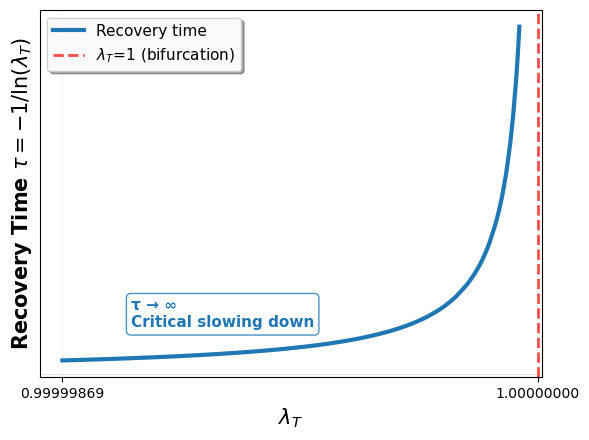

In [20]:
lam_scan = eigenvalues
recovery_time = -1 / np.log(lam_scan + 1e-10)  # 特征恢复时间

fig, ax2 = plt.subplots(figsize=(6, 4.5))

color1 = '#1f77b4'  # 蓝色
# Plot recovery time
ax2.plot(lam_scan, recovery_time, color='#1f77b4', linewidth=3, label='Recovery time')

# Reference lines
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax2.axvline(1, color='red', linestyle='--', linewidth=2, alpha=0.7, label=r'$\lambda_T$=1 (bifurcation)')

# Optimized annotation for the specific λ range
# Calculate position relative to your data range
lambda_min = min(lam_scan)
lambda_max = max(lam_scan)
lambda_range = lambda_max - lambda_min

# Place annotation at 75% of the range from min
x_annotate = lambda_min + 0.15 * lambda_range
# Find corresponding recovery time at that λ
idx_annotate = np.argmin(np.abs(lam_scan - x_annotate))
y_annotate = recovery_time[idx_annotate]

ax2.annotate('τ → ∞\nCritical slowing down', 
            xy=(x_annotate, y_annotate), 
            xytext=(x_annotate, y_annotate * 3),
            # arrowprops=dict(arrowstyle='->', color='red', lw=2, connectionstyle="arc3,rad=0.1"),
            fontsize=11, color='#1f77b4' , fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='#1f77b4'))

# Customize x-ticks for your specific range
from matplotlib.ticker import FuncFormatter

def format_ticks(x, p):
    return f'{x:.8f}'

# # Generate ticks at meaningful positions
# tick_positions = [0.999996, 0.999997, 0.999998, 0.999999, 1.0]
# # Filter to only include ticks within your data range
# tick_positions = [t for t in tick_positions if t >= lambda_min - 0.0000005 and t <= lambda_max + 0.0000005]

tick_positions = [lambda_min,1.0]
ax2.set_xticks(tick_positions)
# 使用ScalarFormatter强制显示为小数
# x_formatter = ScalarFormatter(useOffset=False)
# x_formatter.set_scientific(False)  # 禁用科学计数法
# ax2.xaxis.set_major_formatter(x_formatter)
ax2.xaxis.set_major_formatter(FuncFormatter(format_ticks))
# ax2.tick_params(axis='x', rotation=45)  # Rotate for better readability

# Set x-axis limits with small padding
# ax2.set_xlim(lambda_min - 0.0000002, lambda_max + 0.0000002)

# Labels with math formatting
ax2.set_xlabel(r'$\lambda_T$', fontsize=15, fontweight='bold')
ax2.set_ylabel(r'Recovery Time $\tau = -1/\ln(\lambda_T)$', fontsize=15, fontweight='bold')
# ax2.set_xticks([])
ax2.set_yticks([])

# Legend
ax2.legend(fontsize=11, framealpha=0.95, fancybox=True, shadow=True)

# Grid with better styling
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax2.set_axisbelow(True)

# Add a zoomed inset if needed (optional)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Uncomment below if you want a zoomed view near λ=1
# axins = inset_axes(ax2, width="40%", height="40%", loc='upper left')
# axins.plot(lam_scan, recovery_time, 'r-', linewidth=2)
# axins.axvline(1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
# axins.set_xlim(0.999999, 1.0000001)
# axins.set_ylim(0, 200)
# axins.grid(True, alpha=0.2)
# mark_inset(ax2, axins, loc1=2, loc2=4, fc="none", ec="gray", linewidth=1)

plt.savefig(result_dir+f'critical_slowing_down_{modes[1]}.png',bbox_inches='tight',dpi=300)
plt.tight_layout()
plt.show()